In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask.array as da
import dask
import zarr
import xarray as xr
import cftime
import os

In [2]:
# # ============== LOAD LLC ==============
# llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
# llc_patch_full = xr.open_zarr(llc_path)

llc_patch_full = xr.open_zarr('/orcd/data/abodner/003/LLC4320/LLC4320',consolidated=False).isel(
    face=1,
    i=slice(2880,3600),
    i_g=slice(2880,3600),
    j=slice(720,1440),
    j_g=slice(720,1440),
)
# quad: i=[2880:4320), j=[0:1440)
# Agulhas: i=[2880:3600), j=[720:1440)
# ============== LOAD EMULATORS ==============
emulator_configs = [
    {
        'name': 'rb-pred-resid-eager-ckpt-40',
        'key': 'emulator_1',
        'path': '/orcd/data/abodner/002/cody/inference_patch/2026-07-15-eval:Samudra_LLC:rb-Agulhas-pred_resid-reg-ckpt40-17993072/predictions_4d.zarr',
        'desc': ''
    },
    #     {
    #     'name': 'rb-pred-resid-reg-ckpt-25',
    #     'key': 'emulator_2',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/2026-07-13-eval:Samudra_LLC:rb-Agulhas-pred_resid-reg-ckpt25-17850330/predictions_4d.zarr',
    #     'desc': ''
    # },
    # {
    #     'name': 'rb-Agulhas-strides=1-pred_field-ckpt-25',
    #     'key': 'emulator_2',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/rb/2026-07-06-eval:Samudra_LLC:rb-Agulhas-strides=1-pred_field-ckpt-25-17335589/predictions_4d.zarr',
    #     'desc': ''   
    # },

]


# ============== OPEN EMULATOR DATASETS ==============
emulator_patches_raw = {}
for cfg in emulator_configs:
    emulator_patches_raw[cfg['key']] = xr.open_dataset(cfg['path'], consolidated=True)
    print(f"Loaded {cfg['name']}: {cfg['desc']}")

# ============== TIME MATCHING ==============
def normalize_times(times):
    return pd.DatetimeIndex([
        pd.Timestamp(
            int(t.year), int(t.month), int(t.day),
            int(t.hour), int(t.minute), int(t.second)
        )
        if hasattr(t, "year")
        else pd.Timestamp(t).floor("s")
        for t in times
    ])

llc_times_norm = normalize_times(llc_patch_full.time.values)

common_times = llc_times_norm
for cfg in emulator_configs:
    emulator_times_norm = normalize_times(emulator_patches_raw[cfg['key']].time.values)
    common_times = common_times.intersection(emulator_times_norm)

common_times = common_times.sort_values()

llc_mask = llc_times_norm.isin(common_times)
llc_patch = llc_patch_full.isel(time=llc_mask)

print(f"LLC subset to {len(common_times)} common times")

# ============== PORT GRID VARS & BUILD UNIFIED STRUCTURE ==============
grid_vars = ['XC', 'YC', 'rA', 'Z']

emulator_patches = {}
for cfg in emulator_configs:
    patch_raw = emulator_patches_raw[cfg['key']]
    patch_times_norm = normalize_times(patch_raw.time.values)

    patch_mask = patch_times_norm.isin(common_times)
    patch = patch_raw.isel(time=patch_mask)

    for gv in grid_vars:
        patch[gv] = llc_patch[gv]

    emulator_patches[cfg['key']] = patch

# ============== UNIFIED REFERENCE LISTS ==============
emulator_info = [(cfg['name'], cfg['key']) for cfg in emulator_configs]
n_emulators = len(emulator_info)

all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

print(f"\n=== Setup complete: LLC + {n_emulators} emulators ===")
for name, key in emulator_info:
    print(f"  {name} ({key})")

Loaded rb-pred-resid-eager-ckpt-40: 
LLC subset to 336 common times

=== Setup complete: LLC + 1 emulators ===
  rb-pred-resid-eager-ckpt-40 (emulator_1)


In [3]:
selected_time_range = [0, 240]   # inclusive indices
stepping = 6                    # 1 = every timestep, 4 = every 4th timestep

start_idx, end_idx = selected_time_range

# ----------------------------------------
# First subset LLC
# ----------------------------------------
llc_patch = llc_patch.isel(
    time=slice(start_idx, end_idx + 1, stepping)
)

# ----------------------------------------
# Then subset each emulator safely
# Handles shorter emulator runs automatically
# ----------------------------------------
emulator_patches_subset = {}

for key, patch in emulator_patches.items():

    max_time = patch.sizes['time']

    # Prevent indexing past emulator length
    safe_end_idx = min(end_idx, max_time - 1)

    patch_subset = patch.isel(
        time=slice(start_idx, safe_end_idx + 1, stepping)
    )

    emulator_patches_subset[key] = patch_subset

emulator_patches = emulator_patches_subset

# ----------------------------------------
# Match LLC length to shortest emulator
# ----------------------------------------
min_time_len = min(
    [llc_patch.sizes['time']] +
    [patch.sizes['time'] for patch in emulator_patches.values()]
)

llc_patch = llc_patch.isel(time=slice(0, min_time_len))

emulator_patches = {
    key: patch.isel(time=slice(0, min_time_len))
    for key, patch in emulator_patches.items()
}

# ----------------------------------------
# Rebuild combined dict
# ----------------------------------------
all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

# ----------------------------------------
# Diagnostics
# ----------------------------------------
print(f"Subset to time indices {start_idx}:{end_idx}")
print(f"Stepping = {stepping}")
print(f"Final synchronized length = {min_time_len}")

print(f"LLC now has {llc_patch.sizes['time']} times")

for name, key in emulator_info:
    print(
        f"{name} ({key}) now has "
        f"{emulator_patches[key].sizes['time']} times"
    )

Subset to time indices 0:240
Stepping = 6
Final synchronized length = 41
LLC now has 41 times
rb-pred-resid-eager-ckpt-40 (emulator_1) now has 41 times


In [4]:
def as_dask(x):
    return x.data if isinstance(x.data, da.Array) else da.from_array(x.data)

def safe_norm(num, den):
    return da.where((den == 0) | da.isnan(den), np.nan, num / den)


In [7]:
out_dir = 'figs/prognostic_var_comparison'
os.makedirs(out_dir, exist_ok=True)

n_times = llc_patch.sizes['time']
time_indices = np.arange(1, n_times)

var_colours = {
'Theta': {'Pe': '#EC5A5E', 'Re': '#E62A2E'},
'Salt': {'Pe': '#9A62AD', 'Re': '#631980'},
'U': {'Pe': '#4F127B', 'Re': '#2A0A42'},
'V': {'Pe': '#FDB995', 'Re': '#FC9065'},
}

def plot_single_var(var, title, out_prefix):
    for emu_name, emu_key in emulator_info:
        print(f"Generating {title} curves for emulator: {emu_name}...")

        fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

        print(f"  Processing {var}...")

        llc_depth = as_dask(llc_patch[var].isel(k=slice(0, 51)))
        llc_t1_depth = llc_depth[:-1, :, :, :]
        llc_t2_depth = llc_depth[1:, :, :, :]

        emu_depth = as_dask(emulator_patches[emu_key][var].isel(k=slice(0, 51)))
        emu_t1_depth = emu_depth[:-1, :, :, :]
        emu_t2_depth = emu_depth[1:, :, :, :]

        Pe_k = da.nanmean(
            da.abs(llc_t2_depth - emu_t2_depth),
            axis=(-2, -1)
        )

        Re_k_first = da.nanmean(
            da.abs(llc_t1_depth[:1, :, :, :] - emu_t2_depth[:1, :, :, :]),
            axis=(-2, -1)
        )

        if n_times > 2:
            Re_k_rollout = da.nanmean(
                da.abs(emu_t1_depth[1:, :, :, :] - emu_t2_depth[1:, :, :, :]),
                axis=(-2, -1)
            )
            Re_k = da.concatenate([Re_k_first, Re_k_rollout], axis=0)
        else:
            Re_k = Re_k_first

        Pe, Re = dask.compute(
            da.nanmean(Pe_k, axis=1),
            da.nanmean(Re_k, axis=1),
        )

        ax.plot(
            time_indices,
            Pe,
            marker='o',
            linewidth=2,
            markersize=4,
            color=var_colours[var]['Pe'],
            label=f'{var} Pe'
        )

        ax.plot(
            time_indices,
            Re,
            marker='o',
            linewidth=2,
            markersize=4,
            color=var_colours[var]['Re'],
            linestyle='--',
            label=f'{var} Re'
        )

        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#E3E3E3')

        ax.set_xlabel('Autoregressive Step')
        ax.set_ylabel('MAE')
        ax.set_title(f'{title}: {emu_name}', fontsize=14)

        ax.legend(fontsize=7, loc='upper left')

        plt.tight_layout()

        safe_emu_name = str(emu_name).replace(' ', '_').replace('/', '_')
        out_filename = f'{out_prefix}_{safe_emu_name}.png'
        out_path = os.path.join(out_dir, out_filename)

        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.close()

        print(f"Saved {out_path}")

plot_single_var('Theta', 'Theta', 'Theta')
plot_single_var('Salt', 'Salt', 'Salt')
plot_single_var('U', 'U', 'U')
plot_single_var('V', 'V', 'V')

Generating Theta curves for emulator: rb-pred-resid-eager-ckpt-40...
  Processing Theta...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 36
  result = blockwise(


Saved figs/prognostic_var_comparison/Theta_rb-pred-resid-eager-ckpt-40.png
Generating Salt curves for emulator: rb-pred-resid-eager-ckpt-40...
  Processing Salt...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 36
  result = blockwise(


Saved figs/prognostic_var_comparison/Salt_rb-pred-resid-eager-ckpt-40.png
Generating U curves for emulator: rb-pred-resid-eager-ckpt-40...
  Processing U...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 36
  result = blockwise(


Saved figs/prognostic_var_comparison/U_rb-pred-resid-eager-ckpt-40.png
Generating V curves for emulator: rb-pred-resid-eager-ckpt-40...
  Processing V...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 36
  result = blockwise(


Saved figs/prognostic_var_comparison/V_rb-pred-resid-eager-ckpt-40.png


Generating Theta curves for emulator: rb-pred-resid-eager-ckpt-40...
  Processing Theta...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 36
  result = blockwise(


ValueError: x and y must have same first dimension, but have shapes (40,) and (1,)

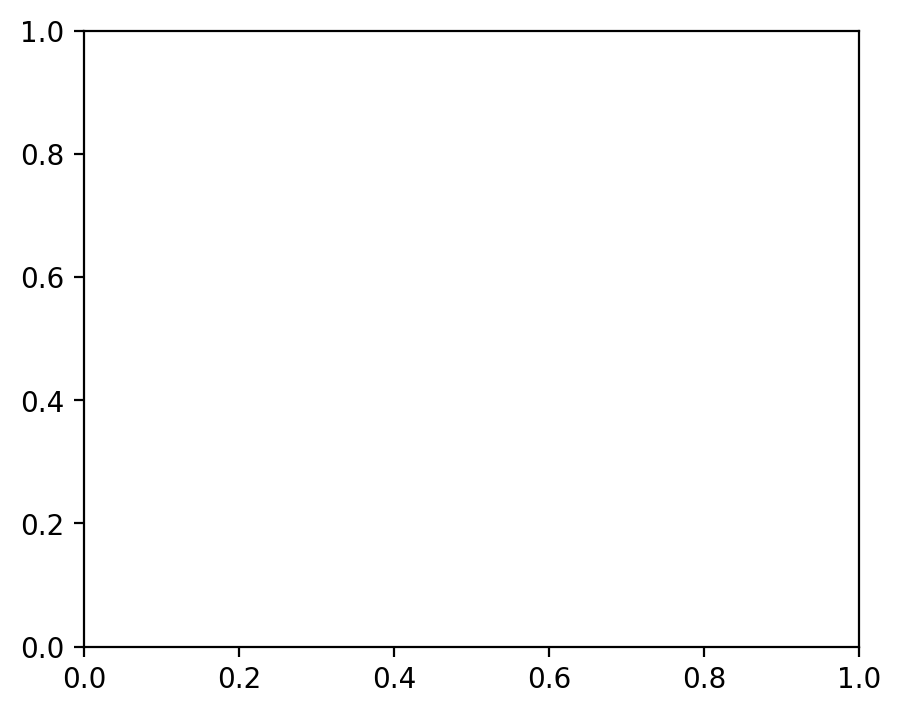

In [ ]:
out_dir = 'figs/prognostic_var_comparison'
os.makedirs(out_dir, exist_ok=True)

n_times = llc_patch.sizes['time']
time_indices = np.arange(1, n_times)

var_colours = {
    'Theta': {'Pe': '#EC5A5E', 'Re': '#E62A2E'},
    'Salt':  {'Pe': '#9A62AD', 'Re': '#631980'},
    'U':     {'Pe': '#4F127B', 'Re': '#2A0A42'},
    'V':     {'Pe': '#FDB995', 'Re': '#FC9065'},
}


def plot_grouped_vars(var_list, title, out_prefix):
    for emu_name, emu_key in emulator_info:
        print(f"Generating {title} curves for emulator: {emu_name}...")

        fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

        for var in var_list:
            print(f"  Processing {var}...")

            llc_depth = as_dask(llc_patch[var].isel(k=slice(0, 51)))

            llc_t1_depth = llc_depth[:-1, :, :, :]
            llc_t2_depth = llc_depth[1:, :, :, :]

            baseline_k = da.nanmean(
                da.abs(llc_t2_depth - llc_t1_depth),
                axis=(-2, -1)
            )

            emu_depth = as_dask(
                emulator_patches[emu_key][var].isel(k=slice(0, 51))
            )

            emu_t1_depth = emu_depth[:-1, :, :, :]
            emu_t2_depth = emu_depth[1:, :, :, :]

            Pe_k = da.nanmean(
                da.abs(llc_t2_depth - emu_t2_depth),
                axis=(-2, -1)
            )

            Re_k_first = da.nanmean(
                da.abs(llc_t1_depth[:1, :, :, :] - emu_t2_depth[:1, :, :, :]),
                axis=(-2, -1)
            )

            if n_times > 2:
                Re_k_rollout = da.nanmean(
                    da.abs(emu_t1_depth[1:, :, :, :] - emu_t2_depth[1:, :, :, :]),
                    axis=(-2, -1)
                )
                Re_k = da.concatenate([Re_k_first, Re_k_rollout], axis=0)
            else:
                Re_k = Re_k_first

            Pe_norm_depth = da.nanmean(safe_norm(Pe_k, baseline_k), axis=1)
            Re_norm_depth = da.nanmean(safe_norm(Re_k, baseline_k), axis=1)

            Pe_norm, Re_norm = dask.compute(Pe_norm_depth, Re_norm_depth)

            ax.plot(
                time_indices,
                Pe_norm,
                marker='o',
                linewidth=2,
                markersize=4,
                color=var_colours[var]['Pe'],
                label=f'{var} Pe'
            )

            ax.plot(
                time_indices,
                Re_norm,
                marker='o',
                linewidth=2,
                markersize=4,
                color=var_colours[var]['Re'],
                linestyle='--',
                label=f'{var} Re'
            )

        ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#E3E3E3')

        ax.set_xlabel('Autoregressive Step')
        ax.set_ylabel('Normalized MAE')
        ax.set_title(f'{title}: {emu_name}', fontsize=14)

        ax.legend(fontsize=7, loc='upper left')

        plt.tight_layout()

        safe_emu_name = str(emu_name).replace(' ', '_').replace('/', '_')
        out_filename = f'{out_prefix}_{safe_emu_name}.png'
        out_path = os.path.join(out_dir, out_filename)

        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.close()

        print(f"Saved {out_path}")


plot_grouped_vars(['Theta', 'Salt'], 'Thermo', 'thermo')
plot_grouped_vars(['U', 'V'], 'Dynamic', 'dynamic')

In [8]:
vars = ['Theta', 'Salt', 'U', 'V']

out_dir = 'figs/prognostic_var_comparison'
os.makedirs(out_dir, exist_ok=True)

n_times = llc_patch.sizes['time']
time_indices = np.arange(1, n_times)

for var in vars:
    print(f"Generating depth-integrated plot for {var}...")

    out_path = os.path.join(out_dir, f'{var}.png')

    fig, ax = plt.subplots(figsize=(7, 4), dpi=200)

    llc_depth = as_dask(llc_patch[var].isel(k=slice(0, 51)))

    llc_t1_depth = llc_depth[:-1, :, :, :]
    llc_t2_depth = llc_depth[1:, :, :, :]

    baseline_k = da.nanmean(
        da.abs(llc_t2_depth - llc_t1_depth),
        axis=(-2, -1)
    )

    for emu_name, emu_key in emulator_info:
        emu_depth = as_dask(emulator_patches[emu_key][var].isel(k=slice(0, 51)))

        emu_t1_depth = emu_depth[:-1, :, :, :]
        emu_t2_depth = emu_depth[1:, :, :, :]

        Pe_k = da.nanmean(
            da.abs(llc_t2_depth - emu_t2_depth),
            axis=(-2, -1)
        )

        Re_k_first = da.nanmean(
            da.abs(llc_t1_depth[:1, :, :, :] - emu_t2_depth[:1, :, :, :]),
            axis=(-2, -1)
        )

        if n_times > 2:
            Re_k_rollout = da.nanmean(
                da.abs(emu_t1_depth[1:, :, :, :] - emu_t2_depth[1:, :, :, :]),
                axis=(-2, -1)
            )
            Re_k = da.concatenate([Re_k_first, Re_k_rollout], axis=0)
        else:
            Re_k = Re_k_first

        Pe_norm_depth = da.nanmean(safe_norm(Pe_k, baseline_k), axis=1)
        Re_norm_depth = da.nanmean(safe_norm(Re_k, baseline_k), axis=1)

        Pe_norm, Re_norm = dask.compute(Pe_norm_depth, Re_norm_depth)

        ax.plot(
            time_indices,
            Pe_norm,
            marker='o',
            linewidth=2,
            color='k',
            markersize=4,
            label='Pe'
        )

        ax.plot(
            time_indices,
            Re_norm,
            marker='o',
            linewidth=2,
            markersize=4,
            color='#FC9065',
            linestyle='--',
            label='Re'
        )

    ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#E3E3E3')

    ax.set_xlabel('Autoregressive Step')
    ax.set_ylabel('Normalized MAE')
    ax.set_title(f'{var}', fontsize=14)

    ax.legend(fontsize=8, loc='best')

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()

    print(f"Saved {out_path}")

Generating depth-integrated plot for Theta...
Saved figs/prognostic_var_comparison/Theta.png
Generating depth-integrated plot for Salt...
Saved figs/prognostic_var_comparison/Salt.png
Generating depth-integrated plot for U...
Saved figs/prognostic_var_comparison/U.png
Generating depth-integrated plot for V...
Saved figs/prognostic_var_comparison/V.png


In [ ]:
vars = ['Theta', 'Salt', 'U', 'V']

out_dir = 'figs/prognostic_var_comparison'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'Prediction_Replication_Erors.png')

n_times = llc_patch.sizes['time']
time_indices = np.arange(1, n_times)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(10, 10),
    dpi=200,
    sharex=True
)


for row, var in enumerate(vars):
    # print(f"Generating plots for {var}...")

    # # ==================================================
    # # Surface arrays: expected shape = time, y, x
    # # ==================================================
    # llc_surf = as_dask(llc_patch[var].isel(k=0))

    # llc_t1_surf = llc_surf[:-1, :, :]
    # llc_t2_surf = llc_surf[1:, :, :]

    # baseline_surf = da.nanmean(
    #     da.abs(llc_t2_surf - llc_t1_surf),
    #     axis=(-2, -1)
    # )

    # ax = axes[row, 0]

    # for emu_name, emu_key in emulator_info:
    #     emu_surf = as_dask(emulator_patches[emu_key][var].isel(k=0))
    #     emu_t1_surf = emu_surf[:-1, :, :]
    #     emu_t2_surf = emu_surf[1:, :, :]

    #     Pe_surf = da.nanmean(
    #         da.abs(llc_t2_surf - emu_t2_surf),
    #         axis=(-2, -1)
    #     )

    #     Re_surf_first = da.nanmean(
    #         da.abs(llc_t1_surf[:1, :, :] - emu_t2_surf[:1, :, :]),
    #         axis=(-2, -1)
    #     )
    #     if n_times > 2:
    #         Re_surf_rollout = da.nanmean(
    #             da.abs(emu_t1_surf[1:, :, :] - emu_t2_surf[1:, :, :]),
    #             axis=(-2, -1)
    #         )
    #         Re_surf = da.concatenate([Re_surf_first, Re_surf_rollout], axis=0)
    #     else:
    #         Re_surf = Re_surf_first

    #     Pe_norm, Re_norm = dask.compute(
    #         safe_norm(Pe_surf, baseline_surf),
    #         safe_norm(Re_surf, baseline_surf)
    #     )

    #     ax.plot(time_indices, Pe_norm, marker='o', linewidth=1.5,
    #             markersize=3, label=f'{emu_name} Pe')
    #     ax.plot(time_indices, Re_norm, marker='o', linewidth=1.5,
    #             markersize=3, linestyle='--', label=f'{emu_name} Re')

    # ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
    # ax.grid(True, alpha=0.3)
    # ax.set_facecolor('#E3E3E3')
    # ax.set_ylabel(f'{var}\nNormalized MAE')

    # ==================================================
    # Depth-averaged arrays: expected shape = time, k, y, x
    # ==================================================
    llc_depth = as_dask(llc_patch[var].isel(k=slice(0, 51)))

    llc_t1_depth = llc_depth[:-1, :, :, :]
    llc_t2_depth = llc_depth[1:, :, :, :]

    baseline_k = da.nanmean(
        da.abs(llc_t2_depth - llc_t1_depth),
        axis=(-2, -1)
    )

    ax = axes[row, 1]

    for emu_name, emu_key in emulator_info:
        emu_depth = as_dask(emulator_patches[emu_key][var].isel(k=slice(0, 51)))
        emu_t1_depth = emu_depth[:-1, :, :, :]
        emu_t2_depth = emu_depth[1:, :, :, :]

        Pe_k = da.nanmean(
            da.abs(llc_t2_depth - emu_t2_depth),
            axis=(-2, -1)
        )

        Re_k_first = da.nanmean(
            da.abs(llc_t1_depth[:1, :, :, :] - emu_t2_depth[:1, :, :, :]),
            axis=(-2, -1)
        )
        if n_times > 2:
            Re_k_rollout = da.nanmean(
                da.abs(emu_t1_depth[1:, :, :, :] - emu_t2_depth[1:, :, :, :]),
                axis=(-2, -1)
            )
            Re_k = da.concatenate([Re_k_first, Re_k_rollout], axis=0)
        else:
            Re_k = Re_k_first

        Pe_norm_depth = da.nanmean(safe_norm(Pe_k, baseline_k), axis=1)
        Re_norm_depth = da.nanmean(safe_norm(Re_k, baseline_k), axis=1)

        Pe_norm, Re_norm = dask.compute(Pe_norm_depth, Re_norm_depth)

        ax.plot(time_indices, Pe_norm, marker='o', linewidth=1.5,
                markersize=3, label=f'{emu_name} Pe')
        ax.plot(time_indices, Re_norm, marker='o', linewidth=1.5,
                markersize=3, linestyle='--', label=f'{emu_name} Re')

    ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
    ax.set_facecolor('#E3E3E3')
    ax.grid(True, alpha=0.3)

    if row == 0:
        axes[row, 0].set_title('Surface', fontweight='bold')
        axes[row, 1].set_title('Depth-Averaged', fontweight='bold')

    if row == len(vars) - 1:
        axes[row, 0].set_xlabel('Autoregressive Step')
        axes[row, 1].set_xlabel('Autoregressive Step')

axes[0, 1].legend(fontsize=8, loc='best')

fig.suptitle('Prediction and Replication Errors by Variable', fontweight='bold')
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.close()

Generating plots for Theta...
Generating plots for Salt...


In [ ]:
# ==================================================
# Depth- and Variable-Integrated Stability Figure
# ==================================================

vars = ['Theta', 'Salt', 'U', 'V']

out_dir = 'figs/prognostic_var_comparison'
os.makedirs(out_dir, exist_ok=True)

combined_out_path = os.path.join(
    out_dir,
    'Depth_Variable_Integrated_Prediction_Replication_Error.png'
)


n_times = llc_patch.sizes['time']
time_indices = np.arange(1, n_times)

fig, ax = plt.subplots(figsize=(7, 4), dpi=200)

for emu_name, emu_key in emulator_info:
    Pe_vars = []
    Re_vars = []

    for var in vars:
        print(f"Calculating combined stability for {var}, {emu_name}...")

        # LLC: time, k, y, x
        llc_depth = as_dask(llc_patch[var].isel(k=slice(0, 51)))
        emu_depth = as_dask(emulator_patches[emu_key][var].isel(k=slice(0, 51)))

        llc_t1 = llc_depth[:-1, :, :, :]
        llc_t2 = llc_depth[1:, :, :, :]

        emu_t1 = emu_depth[:-1, :, :, :]
        emu_t2 = emu_depth[1:, :, :, :]

        # Baseline LLC2 - LLC1 error, shape: time-1, k
        baseline_k = da.nanmean(
            da.abs(llc_t2 - llc_t1),
            axis=(-2, -1)
        )

        # Prediction error, shape: time-1, k
        Pe_k = da.nanmean(
            da.abs(llc_t2 - emu_t2),
            axis=(-2, -1)
        )

        # Replication error, shape: time-1, k
        Re_k_first = da.nanmean(
            da.abs(llc_t1[:1, :, :, :] - emu_t2[:1, :, :, :]),
            axis=(-2, -1)
        )

        if n_times > 2:
            Re_k_rollout = da.nanmean(
                da.abs(emu_t1[1:, :, :, :] - emu_t2[1:, :, :, :]),
                axis=(-2, -1)
            )
            Re_k = da.concatenate([Re_k_first, Re_k_rollout], axis=0)
        else:
            Re_k = Re_k_first

        # Normalize first by LLC2 - LLC1, then integrate over depth
        Pe_norm_depth = da.nanmean(safe_norm(Pe_k, baseline_k), axis=1)
        Re_norm_depth = da.nanmean(safe_norm(Re_k, baseline_k), axis=1)

        Pe_vars.append(Pe_norm_depth)
        Re_vars.append(Re_norm_depth)

    # Integrate over variables
    Pe_combined = da.nanmean(da.stack(Pe_vars, axis=0), axis=0)
    Re_combined = da.nanmean(da.stack(Re_vars, axis=0), axis=0)

    Pe_combined, Re_combined = dask.compute(Pe_combined, Re_combined)

    ax.plot(
        time_indices,
        Pe_combined,
        marker='o',
        linewidth=2,
        color = 'k',
        markersize=4,
        #label=f'{emu_name} Pe'
        label='Pe'
    )

    ax.plot(
        time_indices,
        Re_combined,
        marker='o',
        linewidth=2,
        markersize=4,
        color = '#FC9065',
        linestyle='--',
        #label=f'{emu_name} Re'
        label='Re'
    )

ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#E3E3E3')

ax.set_xlabel('Autoregressive Step')
ax.set_ylabel('Normalized MAE')
#ax.set_title(
#    'Depth and Variable-Integrated Prediction and Replication Error',
#    fontweight='bold'
#)

ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig(combined_out_path, dpi=200, bbox_inches='tight')
plt.close()